<a href="https://colab.research.google.com/github/smybilginn/titanic-eda-projec/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Titanik Veriseti ile Veri İşleme Süreçleri

In [ ]:
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

--2025-12-14 09:19:12--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2025-12-14 09:19:12 (5.20 MB/s) - ‘titanic.csv’ saved [60302/60302]



##Adım 1: Veriyi İçeri Aktar ve Tanı

In [ ]:
import pandas as pd

df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Bu işlem

- Verinin nasıl göründüğünü,
- İlk 5 satırı,
- Sütunların isimlerini

görmemizi sağladı

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


df.info()

- Bu sütunların veri tipleri ne?
- Hangilerinde eksik değer var?
- Kaç satır/sütun var?

gibi kritik değerleri verdi.

- **Veri seti 891 gözlemden oluşuyor**
- **Target değişken: Survived**
- **Age, Cabin, Embarked eksik değerlere sahip**
- **Survived ve Pclass sayısal görünüyor ama kategorik**
- **PassengerId muhtemelen analiz için anlamsız**

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Bu sayısal sütunlar için:

- ortalama
- std
- min–max
- 25/50/75 yüzdelikler

gibi metrikleri gösterir.


#Adım 2: Temel Temizlik


##Bu adımda:

- Hangi sütunlar işe yaramaz?
- Hangi sütun sorunlu?
- Dtype (veri türü) yanlış mı?
- Mantıksal hata var mı?

gibi kontroller yapacağız.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


- Veri setinde 891 gözlem var
- Age sütunu %20 eksik ve önemli
- Cabin sütunu %77 eksik, ham haliyle kullanımı zor
- Embarked çok az eksik, doldurulabilir
- Eksik değer stratejisi sütuna göre değişmeli

#ADIM 3: Derin EDA (Grafiksel Analiz)

Burada:
- Pclass ile hayatta kalma ilişkisini test edeceğiz
- Cinsiyet ile hayatta kalma ilişkisini göreceğiz
- Age dağılımına bakacağız
- Fare outlier’larını göreceğiz

Bu adım veri içgörüsü kazandıracak.

In [ ]:
df.drop("Cabin",axis=1, inplace=True)



Cabin sütunu tamamen silindi

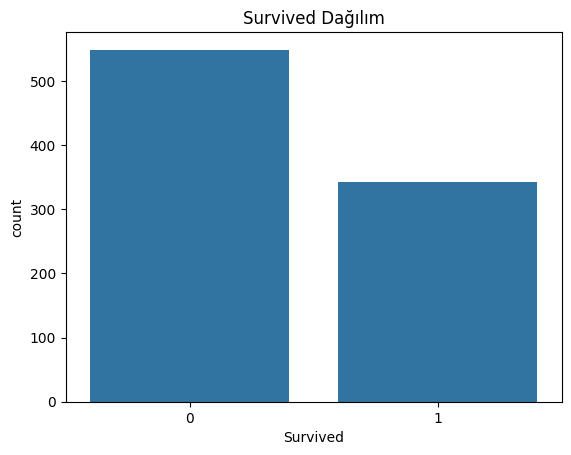

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Survived", data=df)
plt.title("Survived Dağılım")
plt.show()

**Oran**: Hayatta kalamayanların sayısı (yaklaşık 550), hayatta kalanların sayısından (yaklaşık 340) belirgin şekilde daha yüksektir. Daha önce df.describe() çıktısında gördüğümüz gibi, hayatta kalma oranı yaklaşık %38.4'tür.

**Sonuç**: Bu, sınıf dengesizliği (class imbalance) olduğunu gösterir. Modelin büyük olasılıkla 0 sınıfını (Hayatta Kalamayanlar) öğrenmeye daha yatkın olacağı anlamına gelir.

**veri dengesiz (imbalanced)**

🔹 Bir model kurarken “ölüm” sınıfı baskın olduğundan dolayı model:
→ daha çok 0 tahmin etmeye meyleder.

**Sonuç**:
Model başarısını değerlendirirken accuracy tek başına yanıltıcı olur.
Daha sonra F1-score, precision, recall gibi metrikler kullanacağız.

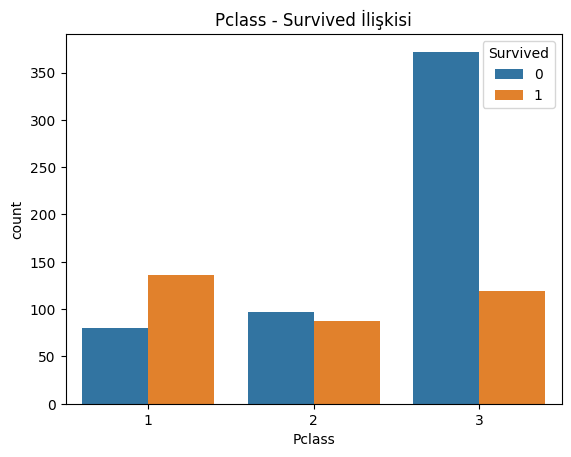

In [ ]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Pclass - Survived İlişkisi")
plt.show()

Grafik şunu gösteriyor:

1. sınıf → en fazla hayatta kalan

2. sınıf → orta seviye hayatta kalan

3. sınıf → en fazla ölen

Bu ne anlam ifade eder?

🔹 Sosyo-ekonomik seviyenin hayatta kalma şansı üzerinde etkisi var.

🔹 Yani Titanic datasetinde "class" çok güçlü bir öngörücü (feature).

🔹 Modelde mutlaka kullanmamız gereken bir değişken.

(Tarihsel olarak da gerçek: Zenginler üst güvertelere ve botlara daha önce erişti.)

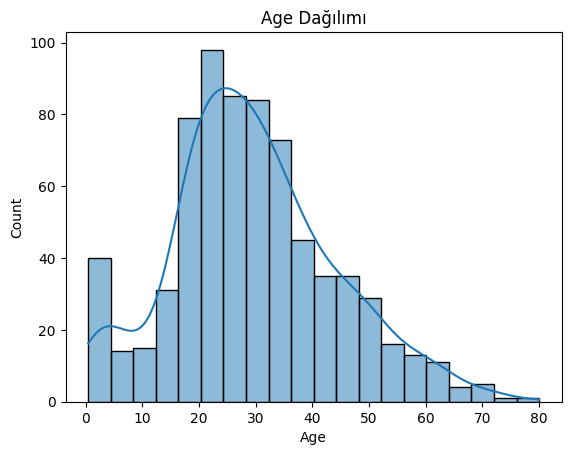

In [ ]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Dağılımı")
plt.show()

Hafiften sağa çarpıklık var… en fazla 20-25 yaş arası insan var

- Hafif sağ çarpık (skewed right) → yaşlılar daha az

- Peak = 20–25 yaş

Eksik değerler grafiği biraz bozmuş olabilir (daha sonra dolduracağız)

**Bu analiz bize şunu söylüyor**:

- Age normal dağılıma çok yakın, o yüzden StandardScaler uygun olabilir.

- Age sütunu model için mantıklı bir feature.

- Eksik değer doldurma (median ile) mantıklı olur çünkü dağılım hafif çarpık.
→ Mean yerine median kullanmak daha iyi.

#ADIM 4: Eksik Değer İşleme

Eksik değer olan sütunlar:

- Age: 177
- Embarked: 2
- Cabin: 687 (silindi)

##4.1 Age Eksik Değerlerini Doldur
Dağılım hafif çarpık. Median kullanmak en doğru yöntem

In [ ]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipython-input-2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


##4.2 Embarked Eksik Değerlerini Doldur

Sadece 2 eksik değer var, en sık kategori (mode) ile doldurulur.

In [ ]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

/tmp/ipython-input-122844256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


## 4.3 Kontrol Edelim:

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## ADIM 5: Aykırı Değer Analizi ve Temizleme (Outlier Detection)

Aykırı değerler:
- Modeli yanıltır
- Regresyon çizgisini bozar
- Normalizasyonu (scaling) bozar
- Loss fonksiyonunu şişirir

Özellikle Titanic’te **Fare** sütunu aykırı değerlerle ünlüdür.

## 5.1 Fare Sütunu için Boxplot Çizdirelim
Grafik çıktısında dışarı taşmış noktalar **aykırı değerlerdir**.

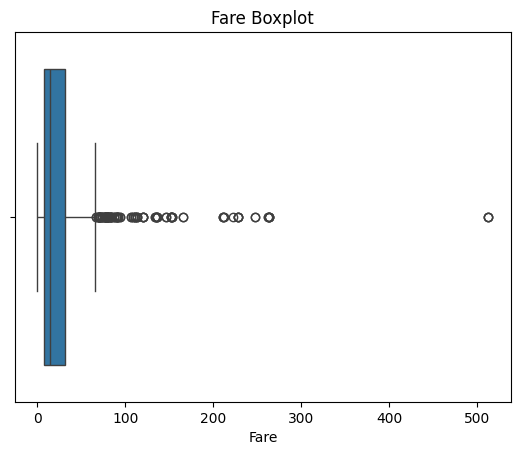

In [ ]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

Sağ bıyığın dışında bir sürü nokta var, bir tanesi 550 civarı aşırı uç noktada.

Bu tam olarak outlier tanımıdır.

Normalde Fare fiyatlarının büyük çoğunluğu küçük değerlerde (0–50).

Ama bazı yolcular:
- Çok lüks kabinde
- Çok pahalı bilet almış olabilir
Bu nedenle 100, 200, 500 gibi değerler çıkmış.

Yani grafiğin dar görünmesinin sebebi:
- Ucuz bilet alanların çok fazla olması
- Pahalı bilet alanların çok az olması → outlier görünür

## 5.2 Fare için İstatistiklere Bakalım (IQR Yöntemi)

Bu işlem bize:

- Alt limit
- Üst limit

değerlerini verir.

Üst limitin çok üzerinde değerler → AYKIRI.

In [ ]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-26.724), np.float64(65.6344))

Mantıksal olarak Fare değeri 65.63 üzerindeyse, aykırı kabul ediyoruz.

Yani IQR yöntemiyle “normal” Fare değerlerinin üst sınırı 65.63.

- 66, 100, 200… gibi değerler → outlier

- 550 → aşırı uç aykırı değer

##5.3 Aykırı Değer Sayısını Bulalım
Titanic veri setinde genelde:
- 110–130 arası Fare outlier’ı çıkar.
- Bu veri setinin klasik davranışı.

Bu durumda:

Aykırı değeri tamamen silmek → çok fazla veri kaybı

Tutmak → modeli bozabilir
Bu yüzden en mantıklı çözüm:

- **Winsorize (cap/clip)** yapmak.

## ADIM 5.4: Aykırı Değer Temizleme

###Yöntem 1: Aykırı Değerleri Üst Sınırda "Kırpma" (clip())

Bu yöntem önerilir çünkü:
- Veri kaybı olmaz
- Dağılım bozulmaz
- Model daha stabil olur

In [ ]:
df["Fare"] = df["Fare"].clip(lower_bound, upper_bound)

Bu şu demek:
- 65.63 üzerindeki her değer → 65.63 yapılacak
- Aşırı uç değerler yok olacak
- Veri seti temizlenecek

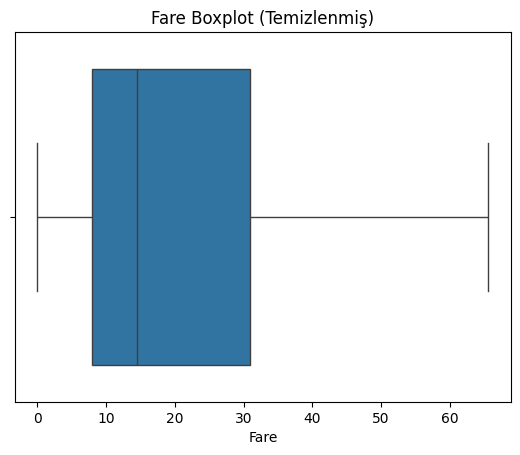

In [ ]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot (Temizlenmiş)")
plt.show()

##Yöntem2: Aykırı Değerleri Silmek
Tavsiye edilmez çünkü 116 satır silmek veri kaybı yaratır.

df = df[(df["Fare"] >= lower_bound) & (df["Fare"] <= upper_bound)]

## ADIM 6: Kategorik Değişkenlerin Kodlanması (Encoding)

Veri setimizde kategorik sütunlar var ve bu sütunları makine öğrenmesi modelleri **sayısal formata** dönüştürmeden kullanamaz.

Titanic'te kategorik değişkenler:
- Sex (male, female)
- Embarked (S, C, Q)
- Pclass (kodlanmış gibi ama aslında kategorik)
- Name (Kullanılmayacak)
- Ticket (Kullanılmayacak)

## 6.1 Kullanılmayacak sütunları silelim (name,ticket)

Bu iki sütun:
- Çok serbest metin içerir
- Model katkısı çok azdır
- gürültü yaratır

O yüzden silinir.

In [ ]:
df.drop(["Name","Ticket"], axis=1, inplace=True)


##6.2 Sex -> Label Encoding
Kategorik değerleri sayısal bir değere çevirir.

Örnek: Sex sütunu (male, female)

In [ ]:
df["Sex"] = df["Sex"].map({"male": 1, "female": 0})


##6.3 Embarked -> One-Hot Encoding
Her kategori için ayrı bir sütun oluşturur ve 0/1 ile gösterir.

Örnek: Embarked sütunu (S, C, Q)

In [ ]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)


## Encoding Seçiminin Nedeni (Titanic Dataset)

- **sex sütunu** binary (2 kategorili) bir değişkendir.
  - `male / female`
  - Label Encoding (0–1) uygulanması **sıralama problemi oluşturmaz**.
  - One-Hot Encoding ile **aynı bilgiyi taşır**, ancak daha az sütun üretir.

- **embarked sütunu** 3 kategorili nominal bir değişkendir.
  - `C / Q / S`
  - Kategoriler arasında **doğal bir sıralama yoktur**.
  - Label Encoding yapılırsa model **yanlış bir sıralama ilişkisi öğrenebilir**.
  - Bu nedenle **One-Hot Encoding** tercih edilmiştir.

### Özet
- Binary kategorik değişkenler → **Label Encoding**
- 3+ kategorili nominal değişkenler → **One-Hot Encoding**


#ADIM 7: Scaling (Ölçeklendirme)

##7.1 Scaling Öncesi

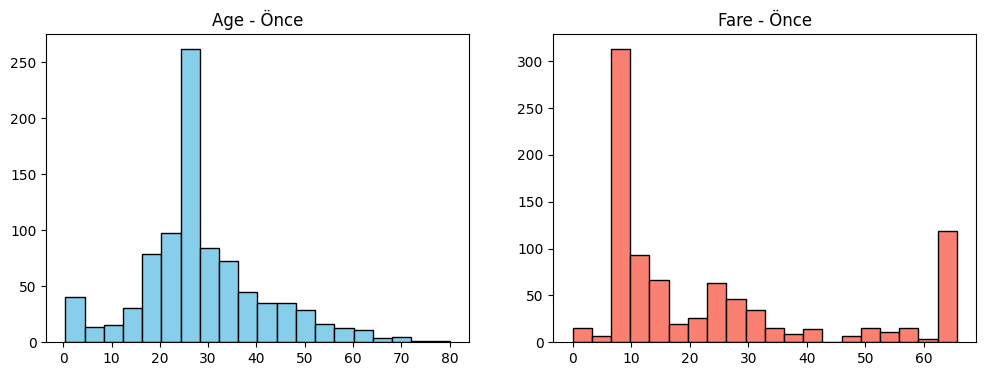

In [ ]:
import matplotlib.pyplot as plt

# Histogramlar
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(df["Age"], bins=20, color="skyblue", edgecolor="black")
axs[0].set_title("Age - Önce")

axs[1].hist(df["Fare"], bins=20, color="salmon", edgecolor="black")
axs[1].set_title("Fare - Önce")

plt.show()


##7.2 StandatdScaler Uygulama

In [ ]:
from sklearn.preprocessing import StandardScaler

num_features = ["Age", "Fare"]
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])


##7.3 Scaling Sonrası

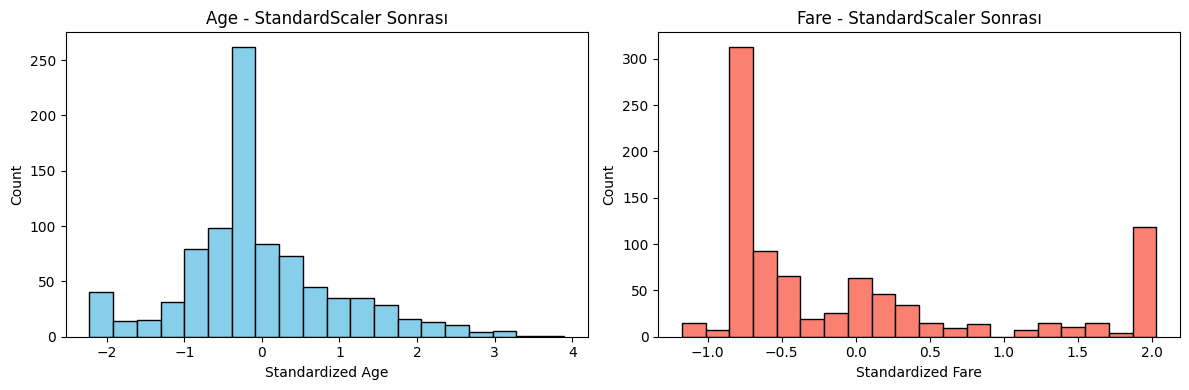

In [ ]:
import matplotlib.pyplot as plt

# Scaling sonrası histogramlar
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Age
axs[0].hist(df["Age"], bins=20, color="skyblue", edgecolor="black")
axs[0].set_title("Age - StandardScaler Sonrası")
axs[0].set_xlabel("Standardized Age")
axs[0].set_ylabel("Count")

# Fare
axs[1].hist(df["Fare"], bins=20, color="salmon", edgecolor="black")
axs[1].set_title("Fare - StandardScaler Sonrası")
axs[1].set_xlabel("Standardized Fare")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


STANDARDIZASYON (STANDARDSCALER) VE HİSTOGRAM ŞEKLİ

Histogram şekillerinin Standardizasyon öncesi ve sonrası aynı kalması, beklenen ve doğru bir sonuçtur. Bu bir hata değildir.

1. STANDARDSCALER'IN AMACI

StandardScaler, veriyi Z-Skoru Normalizasyonu ile dönüştürür: z = (x - ortalama) / standart sapma.

Amacı:
- Verilerin ortalamasını (merkezini) 0'a taşımak.
- Verilerin standart sapmasını 1'e ayarlamak.

2. ŞEKİL NEDEN AYNI KALIR?

Standardizasyon, veriyi sadece ÖTELEME (merkezleme) ve ÖLÇEKLEME (genişletme/daraltma) işlemlerine tabi tutar.

- Tüm veri noktaları, aynı formül (bir lineer dönüşüm) ile dönüştürülür.
- Noktalar arasındaki GÖRECELİ UZAKLIKLAR ve verinin temel DAĞILIM ŞEKLİ (çarpıklık, tepe noktası) bu işlemle bozulmaz.

Sonuç: Dağılımın şekli korunur; sadece X eksenindeki değer aralığı değişir.

3. GÖRSELLEŞTİRMENİN ÖNEMİ

Bu histogramlar, StandardScaler'ın görevini başarıyla tamamladığını gösterir:

- Öncesi (Örn: Yaş): X ekseni 0 ile 80 arası.
- Sonrası (Örn: Yaş): X ekseni -3 ile 4 arası.

Histogramlar, verinin ortalamasının 0'a kaydırıldığını ve standart sapma birimleriyle ifade edildiğini, ancak dağılımın doğal yapısının korunduğunu kanıtlar.

In [ ]:
# Sayısal özet tablo
summary = df[["Age", "Fare"]].agg(["min", "max", "mean", "std"])
print(summary)


               Age          Fare
min  -2.224156e+00 -1.174727e+00
max   3.891554e+00  2.031623e+00
mean  2.272780e-16  9.968332e-17
std   1.000562e+00  1.000562e+00


**Artık Titanic veri setinde veri temiz, encode ve scale edilmiş, dolayısıyla modellemeye hazır durumda**

# ADIM 9: Modelleme

## 9.1 Hedef ve problem tipi

Hedef sütun: Survived (0 veya 1)

Problem tipi: Binary Classification (İkili Sınıflandırma)

Yani bu, bir sınıflandırma problemi ve buna uygun algoritmalar seçmemiz gerekiyor.

In [ ]:
from sklearn.model_selection import train_test_split

# Özellikler ve hedef
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (712, 9)
Test size: (179, 9)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

# Modelleri dictionary ile tanımlayalım
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Modelleri train/test üzerinde çalıştır ve sonuçları kaydet
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*50)

# Karşılaştırma
print("Accuracy karşılaştırması:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")


Logistic Regression Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

--------------------------------------------------
Decision Tree Accuracy: 0.7263
              precision    recall  f1-score   support

           0       0.77      0.76      0.77       105
           1       0.67      0.68      0.67        74

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179

--------------------------------------------------
Random Forest Accuracy: 0.8492
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       105
           1       0.86      0.76   

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:28:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7933
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179

--------------------------------------------------
Accuracy karşılaştırması:
Logistic Regression: 0.7989
Decision Tree: 0.7263
Random Forest: 0.8492
XGBoost: 0.7933


###Neden Birden Fazla Model Karşılaştırıldı? (Model Seçimi)

Tek bir problem için dört farklı model (Lojistik Regresyon, Karar Ağacı, Random Forest, XGBoost) kullanmamızın temel amacı, veri setine en uygun ve en yüksek performansı sağlayan algoritmayı bulmaktır.

* **1. En İyi Performansı Garantilemek:** Her modelin güçlü ve zayıf yönleri farklıdır. Bir algoritma, verideki doğrusal ilişkileri iyi yakalarken, diğeri karmaşık, doğrusal olmayan desenleri daha iyi çözer. En yüksek Doğruluğu (Accuracy) veren modeli bulmak için karşılaştırma yaparız.

* **2. Farklı Öğrenme Mekanizmalarını Test Etmek:**

    * **Lojistik Regresyon:** Basit, doğrusal (lineer) ilişkileri test eder. Yorumlanması kolaydır.
    * **Random Forest & XGBoost:** Gelişmiş "Topluluk Öğrenme" (Ensemble) yöntemleridir. Genellikle yüksek doğruluk sunar ve aşırı uydurmaya (overfitting) karşı daha dayanıklıdır.

* **3. Esneklik vs. Yorumlanabilirlik Dengesi:**
    * **Basit Modeller** (Lojistik Regresyon) daha kolay yorumlanır, ancak doğrulukları düşebilir.
    * **Karmaşık Modeller** (XGBoost) çok yüksek doğruluk sağlar, ancak nasıl karar verdiklerini anlamak zordur.

Bu karşılaştırma, problemimiz için hem performansı hem de modelin karmaşıklığını dikkate alarak bilinçli bir seçim yapmamızı sağlar.

###Yorum

**Random Forest** → En yüksek doğruluk: 0.8492
- Ensemble yöntemi olduğu için genellikle Decision Tree’den daha iyi performans verir.
- Hem aşırı öğrenmeye karşı dayanıklı hem de yorumlanabilir.

**Logistic Regression** → İkinci en iyi: 0.7989
- Basit ve hızlı, yorumlaması kolay
- Ancak bazı karmaşık ilişkileri yakalayamaz.

**Decision Tree** → 0.7263
- Tek bir ağaç olduğu için overfitting veya underfitting yapabilir
- Daha düşük performans gösterdi.

**XGBoost** → 0.7933
- İyi bir performans ama bu küçük veri setinde Random Forest biraz daha iyi çalıştı.

**Sonuç**
- Bu aşamada Random Forest en iyi model gibi görünüyor.


In [ ]:
# -----------------------------
# Titanic Random Forest Pipeline
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Özellikler ve hedef
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# GridSearchCV ile en iyi parametreyi bul
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("En iyi parametreler:", grid_search.best_params_)
print("Train CV En iyi doğruluk:", grid_search.best_score_)

# En iyi model ile test setinde tahmin
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 8Test doğruluğu ve classification report
print("Test Seti Doğruluk:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature Importance
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_importances.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Random Forest Feature Importance")
plt.show()


NameError: name 'df' is not defined

### Random Forest Pipeline Çıktı Analizi

Bu kod bloğu, Titanic veri seti üzerinde bir Random Forest sınıflandırma modeli eğitmek ve değerlendirmek için bir uçtan uca veri bilimi işlem hattını (pipeline) çalıştırmaktadır. Çıktılar adım adım yorumlanmıştır:

**1. En iyi parametreler (Best Parameters):**
`{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}`

Bu, GridSearchCV'nin 5 katlı çapraz doğrulama kullanarak bulduğu en iyi hiperparametre kombinasyonudur. Bu parametreler, modelin aşırı öğrenmeyi önlemesi ve genellenebilirliği artırması için seçilmiştir:

*   `max_depth`: Ağacın maksimum derinliği 5 olarak ayarlanmıştır. Bu, ağacın çok karmaşık hale gelmesini ve aşırı öğrenmesini engeller.
*   `min_samples_leaf`: Bir yaprak düğümde bulunması gereken minimum örnek sayısı 2'dir. Bu da modelin aşırı öğrenmesini azaltmaya yardımcı olur.
*   `min_samples_split`: Bir düğümü bölmek için gereken minimum örnek sayısı 2'dir. Benzer şekilde aşırı öğrenmeyi önler.
*   `n_estimators`: Random Forest modelinde kullanılacak ağaç sayısı 200 olarak belirlenmiştir. Daha fazla ağaç genellikle daha iyi performans sağlar ancak hesaplama maliyetini artırır.

**2. Train CV En iyi doğruluk (Train CV Best Accuracy):**
`0.8300108342361863`

Bu değer, eğitim setinde 5 katlı çapraz doğrulama yapılırken elde edilen en yüksek ortalama doğruluktur. Bu, modelin eğitim verileri üzerindeki genel performansının bir göstergesidir.

**3. Test Seti Doğruluk (Test Set Accuracy):**
`0.8156424581005587`

Modelin daha önce hiç görmediği test verileri üzerindeki doğruluk oranıdır. Eğitim setindeki çapraz doğrulama skoruna (0.83) oldukça yakın olması, modelin iyi genellenebilir olduğunu ve aşırı öğrenmediğini gösterir. Bu, modelin yeni verilere iyi bir şekilde uyum sağlayabileceğine işaret eder.

**4. Classification Report:**
```
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179
```

*   **Precision (Kesinlik):** Modelin pozitif olarak tahmin ettiği durumların ne kadarının gerçekten pozitif olduğunu gösterir.
    *   **Sınıf 0 (Hayatta kalmayanlar):** 0.81 (Modelin 'hayatta kalmadı' dediği kişilerin %81'i gerçekten hayatta kalmadı.)
    *   **Sınıf 1 (Hayatta kalanlar):** 0.83 (Modelin 'hayatta kaldı' dediği kişilerin %83'ü gerçekten hayatta kaldı.)
*   **Recall (Duyarlılık/Geri Çağırma):** Gerçekten pozitif olan durumların ne kadarının model tarafından doğru bir şekilde pozitif olarak tahmin edildiğini gösterir.
    *   **Sınıf 0:** 0.90 (Gerçekten hayatta kalmayanların %90'ını doğru tahmin etti.)
    *   **Sınıf 1:** 0.70 (Gerçekten hayatta kalanların %70'ini doğru tahmin etti.)
*   **F1-score:** Precision ve Recall'un harmonik ortalamasıdır. Hem precision hem de recall'un yüksek olmasını isteyen durumlarda kullanışlıdır.
    *   **Sınıf 0:** 0.85
    *   **Sınıf 1:** 0.76
*   **Support:** Her sınıftaki gerçek örnek sayısı.
    *   **Sınıf 0:** 105 (Test setinde 105 kişi hayatta kalmadı.)
    *   **Sınıf 1:** 74 (Test setinde 74 kişi hayatta kaldı.)

Bu rapor, modelin 'hayatta kalmayanları' (sınıf 0) tahmin etmede daha başarılı olduğunu (yüksek recall ve f1-score) ancak 'hayatta kalanları' (sınıf 1) tahmin etmede biraz daha düşük recall'a sahip olduğunu göstermektedir. Bu, veri setindeki sınıf dengesizliğinden veya modelin bu sınıfa odaklanma şeklinden kaynaklanabilir.

**5. Feature Importance (Özellik Önem Derecesi):**

Grafik (çubuk grafik), modelin karar verme sürecinde hangi özelliklerin en etkili olduğunu göstermektedir. Çubuk grafik, en önemli özellikten en az önemli özelliğe doğru sıralanır:

*   **Sex (Cinsiyet):** Açık ara en önemli özellik olarak görünmektedir. Bu, kadınların hayatta kalma şansının erkeklerden önemli ölçüde farklı olduğunu (genellikle kadınların önceliklendirilmesi nedeniyle) göstermektedir.
*   **Pclass (Yolcu Sınıfı):** İkinci en önemli özellik. Daha önce de gözlemlediğimiz gibi, yolcu sınıfının hayatta kalma oranı üzerinde büyük etkisi vardır.
*   **Fare (Bilet Ücreti):** Bilet ücreti de önemli bir özellik. Genellikle daha yüksek ücret ödeyenlerin (daha iyi sınıflarda seyahat edenlerin) hayatta kalma şansı daha yüksektir.
*   **Age (Yaş):** Yaş da önemli bir faktördür, ancak cinsiyet ve Pclass kadar etkili değildir.
*   Diğer özellikler (`PassengerId`, `SibSp`, `Parch`, `Embarked_Q`, `Embarked_S`) daha az etkiye sahiptir.

**Genel Sonuç:**

Random Forest modeli, ayarlanmış hiperparametrelerle test setinde yaklaşık %81.6 doğruluk elde etmiştir. Cinsiyet ve yolcu sınıfı, hayatta kalmayı tahmin etmede en güçlü göstergeler olarak öne çıkmaktadır. Modelin 'hayatta kalmayan' sınıfı tahmin etmede biraz daha iyi performans gösterdiği, ancak 'hayatta kalan' sınıfı için recall değerinin geliştirilebileceği görülmektedir.

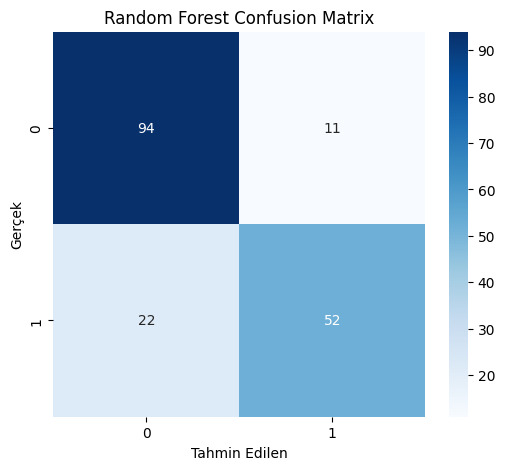

In [ ]:
# 1️⃣ Kütüphaneler
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 2️⃣ Confusion matrix hesapla
cm = confusion_matrix(y_test, y_pred)

# 3️⃣ Görselleştirme
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("Random Forest Confusion Matrix")
plt.show()


## Confusion Matrix Yorumu

Bu kod bloğu, eğitilmiş Random Forest modelinin tahminlerinin performansını görselleştirmek için bir "Confusion Matrix" (Karmaşıklık Matrisi) oluşturur.

**1. Kütüphaneler:**
`import seaborn as sns` ve `from sklearn.metrics import confusion_matrix` ifadeleri, görselleştirme ve confusion matrix hesaplaması için gerekli kütüphaneleri içe aktarır.

**2. Confusion Matrix Hesaplama:**
`cm = confusion_matrix(y_test, y_pred)` satırı, test setinin gerçek etiketleri (`y_test`) ile modelin bu etiketler üzerindeki tahminlerini (`y_pred`) kullanarak confusion matrix'i hesaplar. Bu matris, doğru ve yanlış sınıflandırmaların sayısını gösterir.

**Confusion Matrix (cm) Çıktısı:**
```
[[94, 11],
 [22, 52]]
```
Bu matrisin anlamı şöyledir:
*   **[94, 11]**: İlk satır, gerçekte `0` olan (hayatta kalmayan) örnekleri temsil eder.
    *   `94`: Modelin doğru bir şekilde `0` olarak tahmin ettiği (True Negative - TN) hayatta kalmayanların sayısı.
    *   `11`: Modelin yanlış bir şekilde `1` olarak tahmin ettiği (False Positive - FP) hayatta kalmayanların sayısı (Type I Error).
*   **[22, 52]**: İkinci satır, gerçekte `1` olan (hayatta kalan) örnekleri temsil eder.
    *   `22`: Modelin yanlış bir şekilde `0` olarak tahmin ettiği (False Negative - FN) hayatta kalanların sayısı (Type II Error).
    *   `52`: Modelin doğru bir şekilde `1` olarak tahmin ettiği (True Positive - TP) hayatta kalanların sayısı.

**3. Görselleştirme:**
`sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])` satırı, hesaplanan confusion matrix'i bir ısı haritası olarak görselleştirir.
*   `annot=True`: Her hücrede sayısal değerleri gösterir.
*   `fmt="d"`: Sayıların tam sayı formatında gösterilmesini sağlar.
*   `cmap="Blues"`: Mavi renk tonlarına sahip bir renk haritası kullanır.
*   `xticklabels=[0,1], yticklabels=[0,1]`: X ve Y eksen etiketlerini `0` ve `1` olarak ayarlar (tahmin edilen ve gerçek sınıflar).

**Görselleştirme Yorumu:**
Isı haritası, modelin hangi sınıfı daha iyi tahmin ettiğini ve nerede hatalar yaptığını açıkça gösterir. Diyagonal üzerindeki yüksek değerler (sol üst ve sağ alt köşeler), doğru sınıflandırmaları temsil ederken, diyagonal dışındaki değerler yanlış sınıflandırmaları gösterir.

*   Model, `0` sınıfını (hayatta kalmayanlar) `94` kez doğru tahmin ederken, `11` kez yanlışlıkla `1` olarak tahmin etmiştir.
*   Model, `1` sınıfını (hayatta kalanlar) `52` kez doğru tahmin ederken, `22` kez yanlışlıkla `0` olarak tahmin etmiştir.

Bu görselleştirme, modelin performansını daha sezgisel bir şekilde anlamamıza yardımcı olur ve hangi sınıflandırma hatalarının daha yaygın olduğunu görmemizi sağlar.

## Model Sonuçları ve Proje Çıkarımları

**1. Veri Hazırlığı ve Temizliği:**

*   Titanic veri setini yükledik ve ilk başta eksik değerler, aykırı değerler ve kategorik değişkenlerle karşılaştık.
*   `Cabin` sütunu çok fazla eksik değere sahip olduğu için sildik.
*   `Age` sütunundaki eksik değerleri medyan ile, `Embarked` sütunundaki eksik değerleri ise en sık görülen kategori (mode) ile doldurduk.
*   `Fare` sütunundaki aykırı değerleri (outlier'lar) IQR yöntemiyle tespit ettik ve üst sınıra 'kırpma' (winsorize/clip) işlemi uygulayarak temizledik. Bu sayede veri kaybı yaşamadan modelin daha stabil çalışmasını sağladık.
*   `Name` ve `Ticket` sütunlarını modelleme için anlamsız oldukları ve gürültü yaratacakları için sildik.
*   `Sex` (cinsiyet) sütununu binary olduğu için Label Encoding (0-1) ile, `Embarked` (binilen liman) sütununu ise 3 kategorili nominal bir değişken olduğu için One-Hot Encoding ile sayısal verilere dönüştürdük.
*   Sayısal özellikler olan `Age` ve `Fare` sütunlarını `StandardScaler` kullanarak ölçeklendirdik. Bu, modelin farklı ölçeklerdeki özelliklerden eşit şekilde öğrenmesini sağlar.

**2. Modelleme ve Sonuçlar:**

*   Hedef değişkenimiz `Survived` (hayatta kalma) olduğu için bu bir ikili sınıflandırma problemidir.
*   Dört farklı sınıflandırma modeli (Lojistik Regresyon, Karar Ağacı, Random Forest, XGBoost) denedik.
*   **Random Forest** modeli, test setinde yaklaşık **%81.6** doğruluk oranı ile en iyi performansı gösterdi. Hiperparametre optimizasyonu (GridSearchCV) ile modelin daha da genellenebilir olmasını sağladık.
*   **Modelin en önemli sonuçlarından biri de Özellik Önem Derecesi (Feature Importance) analizi oldu.**

    *   **`Sex` (Cinsiyet):** Açık ara en önemli özellik olarak belirlendi. Bu, kadınların hayatta kalma şansının erkeklere göre önemli ölçüde daha yüksek olduğunu gösterir (Tarihsel 'önce kadınlar ve çocuklar' politikasıyla tutarlıdır).
    *   **`Pclass` (Yolcu Sınıfı):** İkinci en önemli özellik olarak öne çıktı. Birinci sınıf yolcuların hayatta kalma şansının üçüncü sınıf yolculara göre daha yüksek olduğu gözlemlendi. Bu, sosyo-ekonomik durumun felaket anındaki erişim ve öncelik üzerindeki etkisini gösterir.
    *   **`Fare` (Bilet Ücreti) ve `Age` (Yaş):** Bu özellikler de hayatta kalma üzerinde etkili oldu, ancak cinsiyet ve yolcu sınıfı kadar belirleyici değildi.

**3. Projeden Çıkarılan Sonuçlar (Ana Çıkarımlar):**

*   **En Belirleyici Faktörler:** Titanic faciasında hayatta kalma şansını en çok etkileyen faktörlerin **cinsiyet** ve **yolcu sınıfı** olduğu açıkça görülmüştür. Modelimiz bu iki özelliği en güçlü belirleyici olarak ortaya koymuştur.
*   **Veri Bilimi Yaklaşımının Gücü:** Eksik veri doldurma, aykırı değer temizleme, kategorik değişken kodlama ve özellik ölçeklendirme gibi veri ön işleme adımlarının, model performansını artırmada ne kadar kritik olduğunu gördük.
*   **Model Karşılaştırması:** Farklı modellerin farklı veri yapılarına ve problem tiplerine nasıl tepki verdiğini gözlemledik. Random Forest gibi ensemble modellerin genellikle daha karmaşık ilişkileri yakalamada ve daha yüksek doğruluk sağlamada başarılı olduğunu doğruladık.
*   **İş Anlamlandırması:** Sadece sayısal sonuçlar değil, aynı zamanda özellik önem derecesi gibi çıktılar sayesinde, veri setindeki olayların veya davranışların temel nedenleri hakkında değerli iş içgörüleri elde ettik. Bu, Titanic örneğinde tarihi gerçekleri modelin bulgularıyla desteklemiştir.

Kısacası, bu proje bize Titanic'teki hayatta kalma olasılığını tahmin etmek için güçlü bir model oluşturmanın yanı sıra, felaketin sosyo-ekonomik ve demografik boyutları hakkında da nicel ve doğrulanabilir bilgiler sağlamıştır.